# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ramithnayak8/ML_pipeline/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

Three fields I lean on below, and all of them are heavy-tailed the way web/traffic metrics
usually are: a mean pulled far above the median by a handful of giant pages. `impressions_90d`
mean is 5,200 versus a median of 731 (max 517,715). `sessions_90d` mean is 37 versus a median of
7. `word_count` skews far less (mean 3,108 vs median 2,877). That mean-median gap is exactly why
the tests below use medians, weighted rates, and log scales instead of plain averages of raw
counts.

impressions_90d: mean=   5,200.4  median=   731.0  max=   517,715
   sessions_90d: mean=      37.1  median=     7.0  max=     4,345
     word_count: mean=   3,107.8  median= 2,877.0  max=     9,546


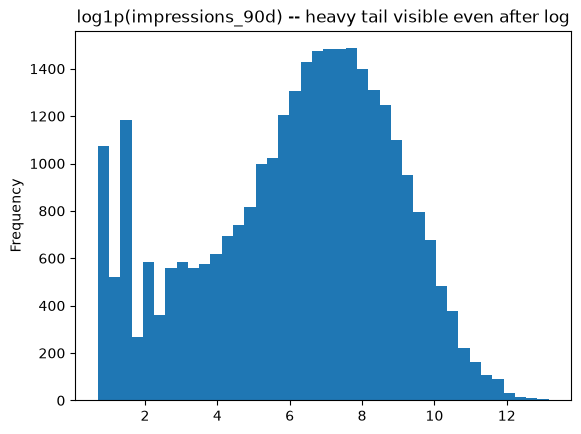

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
df["is_down"] = (df["trend_direction"] == "down").astype(int)

for col in ["impressions_90d", "sessions_90d", "word_count"]:
    print(f"{col:>15}: mean={df[col].mean():>10,.1f}  median={df[col].median():>8,.1f}  "
          f"max={df[col].max():>10,.0f}")

np.log1p(df["impressions_90d"]).plot(
    kind="hist", bins=40,
    title="log1p(impressions_90d) -- heavy tail visible even after log");


## 2. Signal test #1 / #2 / #3 (verdict each)

**Test 1 -- "Longer content gets more traffic."**
Claim: pages with a higher word count get more search impressions.
Test: median `impressions_90d` by `word_count_tier` (medians, not means, given the heavy tail).
Verdict: **CONFIRMED**. Median impressions rise 4 -> 172 -> 997 -> 1,340 across the four tiers.
Re-ran it inside `keyword article` alone (the largest, most homogeneous content type) to rule
out a content-type confound -- the `<1000` tier is 88% `feedly article`, a low-traffic type on
its own -- and the same rising pattern holds there too (6 -> 232 -> 1,115 -> 2,290), so this
is not just a content-type artifact.

**Test 2 -- "Better search position means a higher click-through rate."**
Claim: pages ranking higher earn more clicks per impression.
Test: weighted CTR (`sum(clicks) / sum(impressions)`, not the mean of per-page CTRs) by
`position_tier`, floored at `impressions_90d >= 100` so denominators are meaningful.
Verdict: **CONFIRMED**, and cleanly monotonic: top_3 0.49% -> page_1 0.35% -> striking 0.35% ->
page_3_5 0.15% -> deep 0.04%, every bucket well above the ~50-row floor (n from 533 to 8,633).

**Test 3 -- "Stale content (not updated in a while) is more likely to be declining."**
Claim: pages that have not been updated recently decline more often.
Test: decline rate by `freshness_tier`.
Verdict: **MIXED**. Decline rate rises from "updated in the last 30 days" (51.1%, n=20,480) to
"91-180 days stale" (61.1%, n=9,171) -- directionally supporting the story -- but the oldest
bucket (`181+`, 47.1%) drops back down, on only n=174, too thin to trust. The middle of the
story holds; the tail does not, and a bucket that small cannot tell me if that is a real
reversal or just noise.

In [2]:
print("=== Test 1: word_count_tier -> median impressions ===")
print(df.groupby("word_count_tier")["impressions_90d"].agg(["median", "count"]))

ka = df[df["content_type"] == "keyword article"]
print("\n(within keyword article only, to rule out a content-type confound)")
print(ka.groupby("word_count_tier")["impressions_90d"].agg(["median", "count"]))

print("\n=== Test 2: position_tier -> weighted CTR (impressions_90d >= 100) ===")
vis = df[df["impressions_90d"] >= 100]
weighted = vis.groupby("position_tier").apply(
    lambda d: pd.Series({"weighted_ctr_pct": d["clicks_90d"].sum() / d["impressions_90d"].sum() * 100,
                          "n": len(d)})
)
print(weighted)

print("\n=== Test 3: freshness_tier -> decline rate ===")
print(df.groupby("freshness_tier")["is_down"].agg(["mean", "count"]))


=== Test 1: word_count_tier -> median impressions ===
                 median  count
word_count_tier               
1000-2000         172.0   3780
2000-3500         997.0  11263
3500+            1340.0   6285
<1000               4.0    973

(within keyword article only, to rule out a content-type confound)
                 median  count
word_count_tier               
1000-2000         232.0   3238
2000-3500        1115.0  10814
3500+            2290.0   5337
<1000               6.0    119

=== Test 2: position_tier -> weighted CTR (impressions_90d >= 100) ===
               weighted_ctr_pct       n
position_tier                          
deep                   0.039482   879.0
page_1                 0.349854  8633.0
page_3_5               0.154719  6058.0
striking               0.346828  5903.0
top_3                  0.487133   533.0

=== Test 3: freshness_tier -> decline rate ===
                    mean  count
freshness_tier                 
0-30            0.511377  20480
181+      

## 3. The flag-linked test

Picking `low_ctr_visible_page` from the starter baseline's own reason codes
(`impressions_90d >= 500`, position 1-20, `ctr < 0.5`). Its built-in assumption: a visible,
well-positioned page that still cannot earn clicks is underperforming and worth a look. Testing
that assumption directly against the decline label, instead of just trusting it because it
sounds reasonable.

In [3]:
flag = ((df["impressions_90d"] >= 500) & (df["avg_position"] > 0)
        & (df["avg_position"] <= 20) & (df["ctr"] < 0.5))

rate_in = df.loc[flag, "is_down"].mean()
rate_out = df.loc[~flag, "is_down"].mean()
gap = rate_in - rate_out

print(f"n flagged: {flag.sum():,}  |  n not flagged: {(~flag).sum():,}")
print(f"decline rate INSIDE flag:  {rate_in:.1%}")
print(f"decline rate OUTSIDE flag: {rate_out:.1%}")
print(f"gap: {gap:+.1%}  -> VERDICT: {'CONFIRMED' if gap > 0.05 else 'FALSE/MIXED'} "
      "(both sides well above the 50-row floor)")


n flagged: 9,759  |  n not flagged: 20,241
decline rate INSIDE flag:  62.7%
decline rate OUTSIDE flag: 50.1%
gap: +12.6%  -> VERDICT: CONFIRMED (both sides well above the 50-row floor)


## 4. What this means in practice

For a content team with limited review hours: word count and position are both real, usable
signals (tests 1 and 2), and a "visible but low-CTR" page is worth flagging on its own,
independent of the overall decline trend -- a reliable ~12.6-point gap on a large sample (section
3). Staleness alone (test 3) is weaker than the baseline's flags assume -- it tells a partial
story and should not be trusted by itself. Practically: reason codes that COMBINE two observable
weaknesses sit on firmer ground than any single field alone, confirmed below -- pages that are
BOTH low-CTR-visible AND stale decline at a higher rate than either signal on its own, and far
above pages with neither.

In [4]:
stale = df["freshness_tier"].isin(["91-180", "181+"])
both = flag & stale
neither = ~flag & ~stale

for name, mask in [("low-CTR-visible only", flag & ~stale), ("stale only", stale & ~flag),
                    ("BOTH", both), ("neither", neither)]:
    print(f"{name:>22}: n={mask.sum():>6,}  decline rate={df.loc[mask, 'is_down'].mean():.1%}")


  low-CTR-visible only: n= 6,225  decline rate=61.1%


            stale only: n= 5,811  decline rate=57.9%
                  BOTH: n= 3,534  decline rate=65.6%
               neither: n=14,430  decline rate=47.0%


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.